In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , accuracy_score

In [ ]:
crop_data=pd.read_csv('/content/yield_df.csv')
crop_data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [ ]:
crop_data=crop_data.drop(['Unnamed: 0'],axis=1)
crop_data.head(1)

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37


In [ ]:
crop_data.shape

(28242, 7)

In [ ]:
le_area = LabelEncoder()
le_item = LabelEncoder()
crop_data['Area'] = le_area.fit_transform(crop_data['Area'])
crop_data['Item'] = le_item.fit_transform(crop_data['Item'])

In [ ]:
crop_data.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,36613,1485.0,121.0,16.37
1,0,3,1990,66667,1485.0,121.0,16.37
2,0,4,1990,23333,1485.0,121.0,16.37
3,0,5,1990,12500,1485.0,121.0,16.37
4,0,6,1990,7000,1485.0,121.0,16.37


In [ ]:
crop_data.isnull().sum()

,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


In [ ]:
crop_data.describe()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,46.494724,4.420898,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,26.813405,2.635337,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,24.000000,3.000000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,42.000000,4.000000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,68.000000,7.000000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,100.000000,9.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:
correl=crop_data.corr()
target_corr = correl['hg/ha_yield'].sort_values(ascending=False)
target_corr

,hg/ha_yield
hg/ha_yield,1.000000
Year,0.091630
pesticides_tonnes,0.064085
Area,0.006672
average_rain_fall_mm_per_year,0.000962
avg_temp,-0.114777
Item,-0.225103


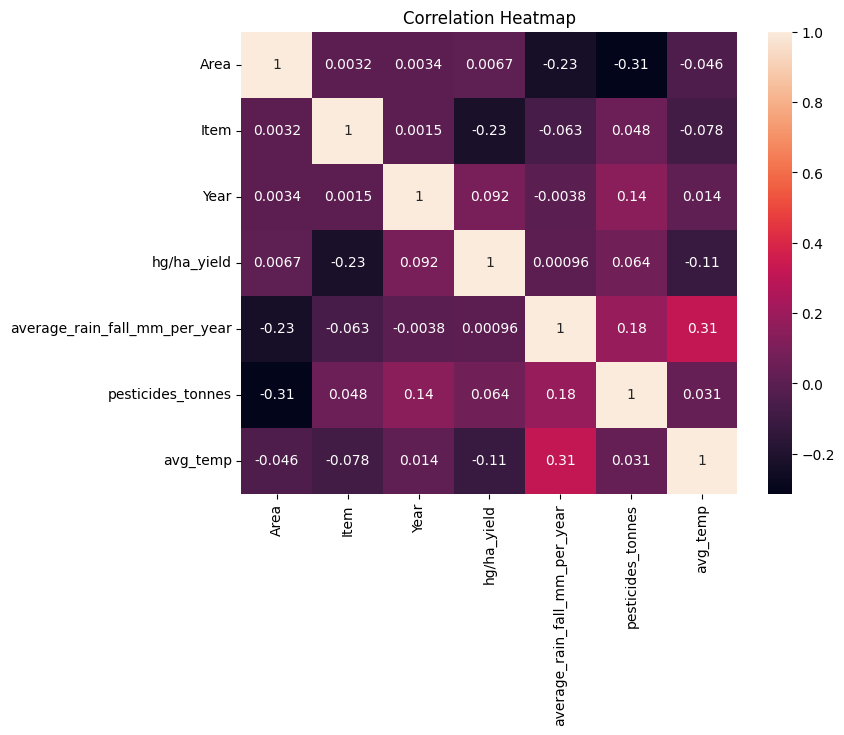

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(crop_data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show( )

In [ ]:
x=crop_data.drop(columns=['hg/ha_yield'], axis=1)
y=crop_data[['hg/ha_yield']]
x.head(),y.head()

(   Area  Item  Year  average_rain_fall_mm_per_year  pesticides_tonnes  \
 0     0     1  1990                         1485.0              121.0   
 1     0     3  1990                         1485.0              121.0   
 2     0     4  1990                         1485.0              121.0   
 3     0     5  1990                         1485.0              121.0   
 4     0     6  1990                         1485.0              121.0   
 
    avg_temp  
 0     16.37  
 1     16.37  
 2     16.37  
 3     16.37  
 4     16.37  ,
    hg/ha_yield
 0        36613
 1        66667
 2        23333
 3        12500
 4         7000)

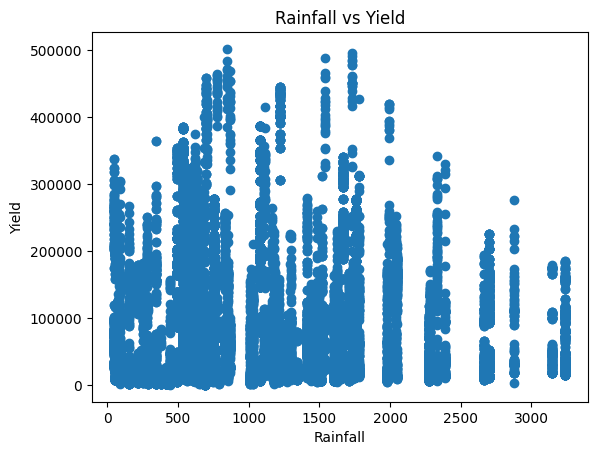

In [ ]:
plt.figure()
plt.scatter(crop_data['average_rain_fall_mm_per_year'], crop_data['hg/ha_yield'])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

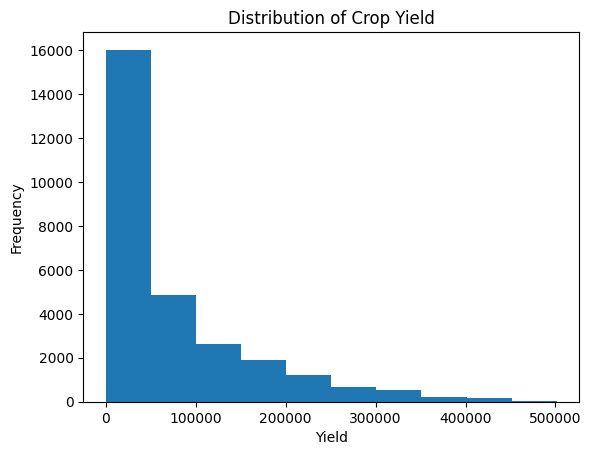

In [ ]:
plt.figure()
plt.hist(crop_data['hg/ha_yield'])
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((22593, 6), (5649, 6), (22593,), (5649,))

In [ ]:
models= {"Linear Regression": LinearRegression(),"SVR": SVR(), "Decision Tree": DecisionTreeRegressor(),"Random Forest": RandomForestRegressor()}
results={}
for name, model in models.items():
    model.fit(x_train, y_train)
    x_test_prediction=model.predict(x_test)
    print(f"Prediction of test data in {name} is {x_test_prediction}")
    mse = mean_squared_error(y_test, x_test_prediction)
    r2 = r2_score(y_test, x_test_prediction)

    results[name] = {"MSE": mse, "R2": r2}


Prediction of test data in Linear Regression is [ 95206.02035279  43756.97675549  90710.57817012 ...  96635.71467353
 122408.29404033  78459.18079068]
Prediction of test data in SVR is [38548.89178589 38376.94827949 38539.40978192 ... 38657.55071988
 38694.41679655 38615.85981267]
Prediction of test data in Decision Tree is [ 69220.  25000.  51206. ... 252775.  24615.  23187.]
Prediction of test data in Random Forest is [ 71731.02  24298.97  51369.71 ... 252632.53  24836.9   22869.65]


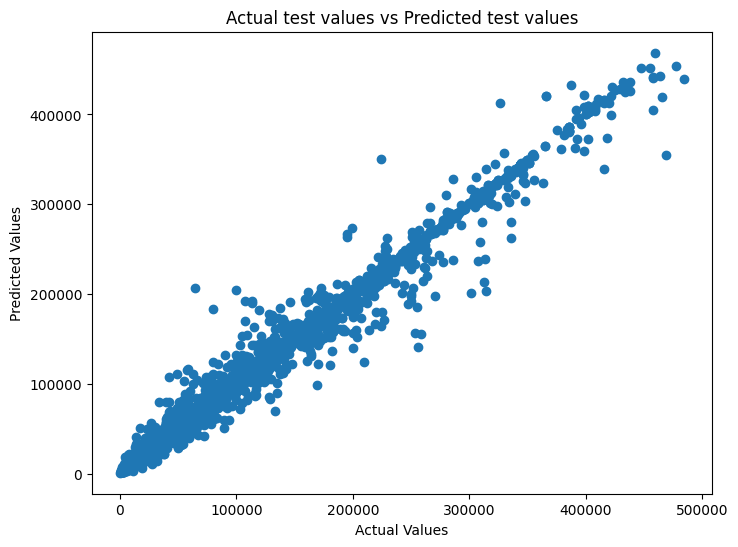

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, x_test_prediction)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual test values vs Predicted test values")
plt.show()

In [ ]:
best_model=None
best_score=-float('inf')
best_model_name=''

for model_name, metrics in results.items():
    print(f"Performance metrics of {model_name}")
    print("MSE:", metrics["MSE"])
    print("R2 Score:", metrics["R2"])
    # Corrected: Use metrics["R2"] for comparison
    if metrics["R2"] > best_score:
        best_score = metrics["R2"]
        best_model_name = model_name


print(f"\nBest Model: {best_model_name} with R2 Score: {best_score}")

Performance metrics of Linear Regression
MSE: 6642537610.981097
R2 Score: 0.08425172276039494
Performance metrics of SVR
MSE: 8739183642.751087
R2 Score: -0.2047944376106925
Performance metrics of Decision Tree
MSE: 177296781.10302708
R2 Score: 0.9755576511020697
Performance metrics of Random Forest
MSE: 102932829.48569733
R2 Score: 0.9858095555052486

Best Model: Random Forest with R2 Score: 0.9858095555052486


Text(0.5, 1.0, 'Model Performance Comparison')

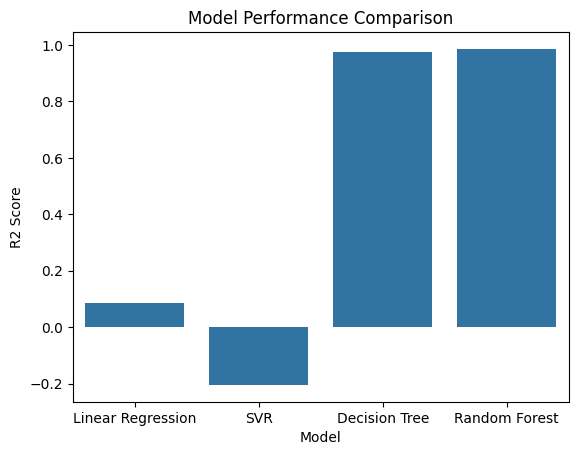

In [ ]:
sns.barplot(x=list(results.keys()), y=[metrics["R2"] for metrics in results.values()])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")